# ✈️ Flight-Focused EDA on the Merged 2024 U.S. Flight–Weather Dataset

This notebook performs exploratory data analysis on the **merged** flight–weather dataset from the **flight operations perspective**.  
The main focus is on:

- delay behavior and target balance (`IS_Delay`)
- airline reliability and operational performance
- time-based patterns across month, season, weekday, and departure hour
- origin, destination, and route-level patterns
- operational delay reasons and how they relate to overall delay behavior

Weather fields remain in the merged dataset, but they are used only as **supporting context** here because the weather-focused EDA is handled separately.

## Why this EDA matters
This analysis builds the foundation for the next stage of the project: predicting whether a flight will be delayed by **more than 15 minutes**. The goal is not only to summarize the data, but also to identify patterns that are meaningful, defensible, and useful for later modeling.

## 0. Setup and scope notes

**Key analytical choices used in this notebook**
- The dataset is already merged, so all analysis uses the merged file as the source.
- The lens is still **flight-centered**, not weather-centered.
- `IS_Delay = 1` means **departure delay > 15 minutes**.
- `Season` and `Departure_Hour` are treated as engineered operational features.
- For route and airline rankings, a **minimum volume threshold** is used where appropriate so that conclusions are not driven by tiny groups.
- The `cancelled` field is checked explicitly. If it has no variation, that is documented as a dataset limitation rather than ignored.

In [38]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from cycler import cycler
from pathlib import Path

# Visual theme: slightly richer colors for a final-submission notebook
PALETTE = ["#0F4C81", "#FF6B6B", "#2A9D8F", "#E9C46A", "#9B5DE5", "#F4A261", "#457B9D", "#8D99AE"]
ACCENT = "#FF6B6B"
DARK = "#0F4C81"
GREEN = "#2A9D8F"
GOLD = "#E9C46A"
PURPLE = "#9B5DE5"
ORANGE = "#F4A261"

sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams['axes.prop_cycle'] = cycler(color=PALETTE)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#FAFAFA'
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


def add_bar_labels(ax, fmt='{:.1%}', pad=3, fontsize=9):
    for p in ax.patches:
        val = p.get_width() if p.get_width() > 0 and abs(p.get_width()) != abs(p.get_height()) else p.get_height()
        if np.isnan(val):
            continue
        if ax.get_xaxis().get_scale() == 'linear' and len(ax.patches) > 0:
            if p.get_width() > p.get_height():
                ax.annotate(fmt.format(val) if '%' in fmt else fmt.format(val),
                            (p.get_width(), p.get_y() + p.get_height()/2),
                            xytext=(pad, 0), textcoords='offset points', va='center', fontsize=fontsize)
            else:
                ax.annotate(fmt.format(val) if '%' in fmt else fmt.format(val),
                            (p.get_x() + p.get_width()/2, p.get_height()),
                            xytext=(0, pad), textcoords='offset points', ha='center', fontsize=fontsize)


## 1. Load data and inspect structure

This section confirms the size of the dataset, the available columns, and the basic data types before any interpretation begins.

In [39]:
from pathlib import Path
import pandas as pd

possible_paths = [
    Path("merged_flights.csv"),
    Path("../merged_flights.csv"),
    Path("../../Merged_Data/merged_flights.csv"),
    Path("Merged_Data/merged_flights.csv"),
    Path("../Merged_Data/merged_flights.csv"),
]

for p in possible_paths:
    if p.exists():
        DATA_PATH = p
        break
else:
    raise FileNotFoundError("merged_flights.csv not found in expected locations")

print("Using file:", DATA_PATH.resolve())

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
df.head()

Using file: /Users/saritaaaaa/Downloads/STT811-Applied Stat/Project/Flight_Delay_Prediction-main/Merged_Data/merged_flights.csv
Shape: 1,343,443 rows × 37 columns


,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin_city,origin_state,dest_city,...,IS_Delay,Season,Departure_Hour,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh,Date,Time,Weather_Data_Present
0,2024,1,1,1,2024-01-01,OO,3862.0,Great Falls,Montana,Salt Lake City,...,0,Winter,5,NaN,NaN,NaN,NaN,NaN,NaN,No
1,2024,1,1,1,2024-01-01,B6,148.0,Las Vegas,Nevada,New York,...,1,Winter,17,NaN,NaN,NaN,NaN,NaN,NaN,No
2,2024,1,1,1,2024-01-01,WN,205.0,Las Vegas,Nevada,Portland,...,0,Winter,17,NaN,NaN,NaN,NaN,NaN,NaN,No
3,2024,1,1,1,2024-01-01,WN,1881.0,Las Vegas,Nevada,Indianapolis,...,1,Winter,17,NaN,NaN,NaN,NaN,NaN,NaN,No
4,2024,1,1,1,2024-01-01,WN,2675.0,Las Vegas,Nevada,Atlanta,...,1,Winter,17,NaN,NaN,NaN,NaN,NaN,NaN,No


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1343443 entries, 0 to 1343442
Data columns (total 37 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   year                  1343443 non-null  int64  
 1   month                 1343443 non-null  int64  
 2   day_of_month          1343443 non-null  int64  
 3   day_of_week           1343443 non-null  int64  
 4   fl_date               1343443 non-null  object 
 5   op_unique_carrier     1343443 non-null  object 
 6   op_carrier_fl_num     1343443 non-null  float64
 7   origin_city           1343443 non-null  object 
 8   origin_state          1343443 non-null  object 
 9   dest_city             1343443 non-null  object 
 10  dest_state            1343443 non-null  object 
 11  crs_dep_time          1343443 non-null  int64  
 12  dep_time              1343443 non-null  float64
 13  dep_delay             1343443 non-null  float64
 14  crs_arr_time          1343443 non-

In [41]:
df.columns.tolist()

['year',
 'month',
 'day_of_month',
 'day_of_week',
 'fl_date',
 'op_unique_carrier',
 'op_carrier_fl_num',
 'origin_city',
 'origin_state',
 'dest_city',
 'dest_state',
 'crs_dep_time',
 'dep_time',
 'dep_delay',
 'crs_arr_time',
 'arr_time',
 'arr_delay',
 'cancelled',
 'crs_elapsed_time',
 'actual_elapsed_time',
 'air_time',
 'carrier_delay',
 'weather_delay',
 'nas_delay',
 'security_delay',
 'late_aircraft_delay',
 'delay_in_minutes',
 'IS_Delay',
 'Season',
 'Departure_Hour',
 'Temperature_C',
 'Humidity_pct',
 'Precipitation_mm',
 'Wind_Speed_kmh',
 'Date',
 'Time',
 'Weather_Data_Present']

## 2. Data quality and preparation

A final EDA should clearly document what is being cleaned, derived, or treated carefully.  
This section checks:

- missing values
- duplicate rows
- data types
- derived flight-focused fields used later in analysis

In [42]:
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .rename("missing_count")
      .to_frame()
)
missing["missing_pct"] = 100 * missing["missing_count"] / len(df)
missing[missing["missing_count"] > 0].head(15)

,missing_count,missing_pct
Time,1234604,91.898503
Date,1234604,91.898503
Wind_Speed_kmh,1234604,91.898503
Precipitation_mm,1234604,91.898503
Humidity_pct,1234604,91.898503
Temperature_C,1234604,91.898503


In [43]:
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count:,}")

Duplicate rows: 0


In [44]:
# Type handling and derived fields
df["fl_date"] = pd.to_datetime(df["fl_date"], errors="coerce")

# Create route for route-level analysis
df["route"] = df["origin_city"].astype(str) + " → " + df["dest_city"].astype(str)

# Ordered categories for cleaner plots
season_order = ["Winter", "Spring", "Summer", "Fall"]
weekday_map = {
    1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu",
    5: "Fri", 6: "Sat", 7: "Sun"
}
month_map = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

df["weekday_name"] = df["day_of_week"].map(weekday_map)
df["month_name"] = df["month"].map(month_map)
df["Season"] = pd.Categorical(df["Season"], categories=season_order, ordered=True)

# Masks used throughout the notebook
operated_mask = df["cancelled"].fillna(0).eq(0)
delayed_mask = df["IS_Delay"].fillna(0).eq(1)

print("Prepared fields added: route, weekday_name, month_name")

Prepared fields added: route, weekday_name, month_name


### Data preparation notes
- Missing values are expected in some merged weather columns because weather coverage was not available for every matched flight-hour.
- Delay-related numeric fields are still useful from the flight perspective because they describe operational outcomes even in the merged dataset.
- Cancellation behavior is handled carefully later instead of assuming the field is usable.

## 3. Overall operational KPI snapshot

This section gives a high-level summary of flight performance in the dataset.  
The goal is to answer:
- How many flights are in the data?
- What share are delayed?
- What is the average departure and arrival delay?
- Is cancellation analysis meaningful in this specific file?

In [45]:
total_flights = len(df)
delayed_flights = int(df["IS_Delay"].sum())
delay_rate = delayed_flights / total_flights

cancelled_flights = int(df["cancelled"].sum())
cancel_rate = cancelled_flights / total_flights

avg_dep_delay = df.loc[operated_mask, "dep_delay"].mean()
avg_arr_delay = df.loc[operated_mask, "arr_delay"].mean()
avg_total_delay = df.loc[operated_mask, "delay_in_minutes"].mean()

kpi = pd.DataFrame({
    "Metric": [
        "Total flights",
        "Delayed flights (IS_Delay = 1)",
        "Delay rate",
        "Cancelled flights",
        "Cancellation rate",
        "Average departure delay (min)",
        "Average arrival delay (min)",
        "Average total delay_in_minutes"
    ],
    "Value": [
        f"{total_flights:,}",
        f"{delayed_flights:,}",
        f"{delay_rate:.2%}",
        f"{cancelled_flights:,}",
        f"{cancel_rate:.2%}",
        f"{avg_dep_delay:.2f}",
        f"{avg_arr_delay:.2f}",
        f"{avg_total_delay:.2f}"
    ]
})
kpi

,Metric,Value
0,Total flights,"1,343,443"
1,Delayed flights (IS_Delay = 1),"393,696"
2,Delay rate,29.31%
3,Cancelled flights,0
4,Cancellation rate,0.00%
5,Average departure delay (min),12.68
6,Average arrival delay (min),7.18
7,Average total delay_in_minutes,19.86


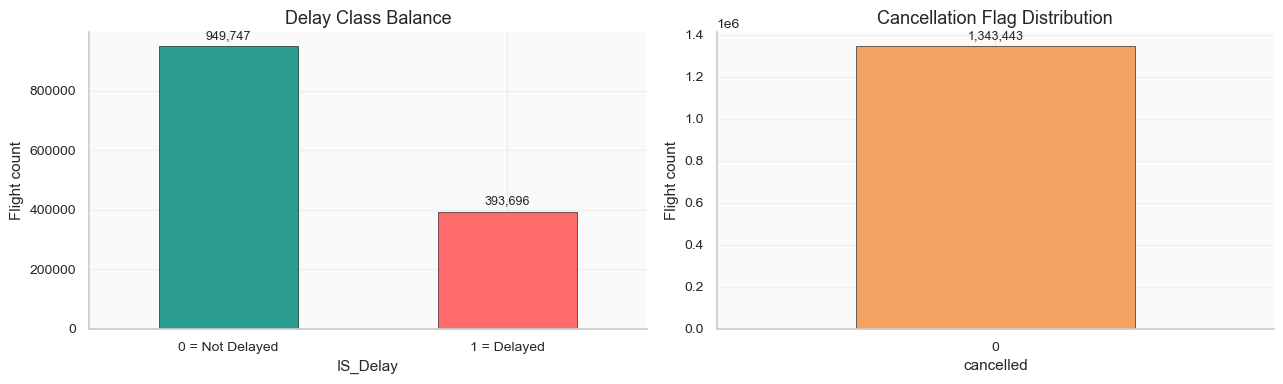

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

is_delay_counts = df["IS_Delay"].value_counts().sort_index()
is_delay_counts.plot(kind="bar", ax=axes[0], color=[GREEN, ACCENT], edgecolor='black', linewidth=0.4)
axes[0].set_title("Delay Class Balance")
axes[0].set_xlabel("IS_Delay")
axes[0].set_ylabel("Flight count")
axes[0].set_xticklabels(["0 = Not Delayed", "1 = Delayed"], rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

cancel_counts = df["cancelled"].value_counts().sort_index()
cancel_counts.plot(kind="bar", ax=axes[1], color=[ORANGE]*len(cancel_counts), edgecolor='black', linewidth=0.4)
axes[1].set_title("Cancellation Flag Distribution")
axes[1].set_xlabel("cancelled")
axes[1].set_ylabel("Flight count")
axes[1].set_xticklabels([str(x) for x in sorted(df["cancelled"].dropna().unique())], rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()


**Interpretation note:**  
If the cancellation flag contains only one value, that should be treated as a **data limitation in this file**, not as evidence that no cancellations occurred in the full real-world system.

## 4. Delay distribution and target balance

This section explores the shape of delay behavior.  
It is useful for understanding:
- whether most flights are close to on time
- how much skew and extreme delay exists
- whether the classification target is imbalanced

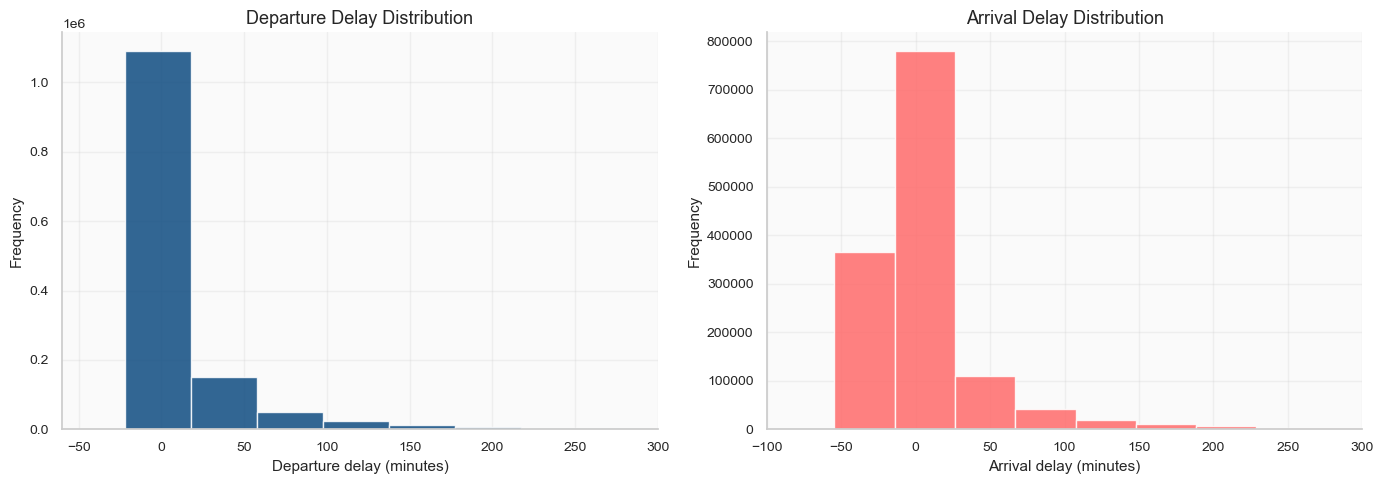

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df.loc[operated_mask, "dep_delay"].dropna(), bins=80, color=DARK, alpha=0.85, edgecolor='white')
axes[0].set_title("Departure Delay Distribution")
axes[0].set_xlabel("Departure delay (minutes)")
axes[0].set_ylabel("Frequency")
axes[0].set_xlim(-60, 300)

axes[1].hist(df.loc[operated_mask, "arr_delay"].dropna(), bins=80, color=ACCENT, alpha=0.85, edgecolor='white')
axes[1].set_title("Arrival Delay Distribution")
axes[1].set_xlabel("Arrival delay (minutes)")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim(-100, 300)

plt.tight_layout()
plt.show()


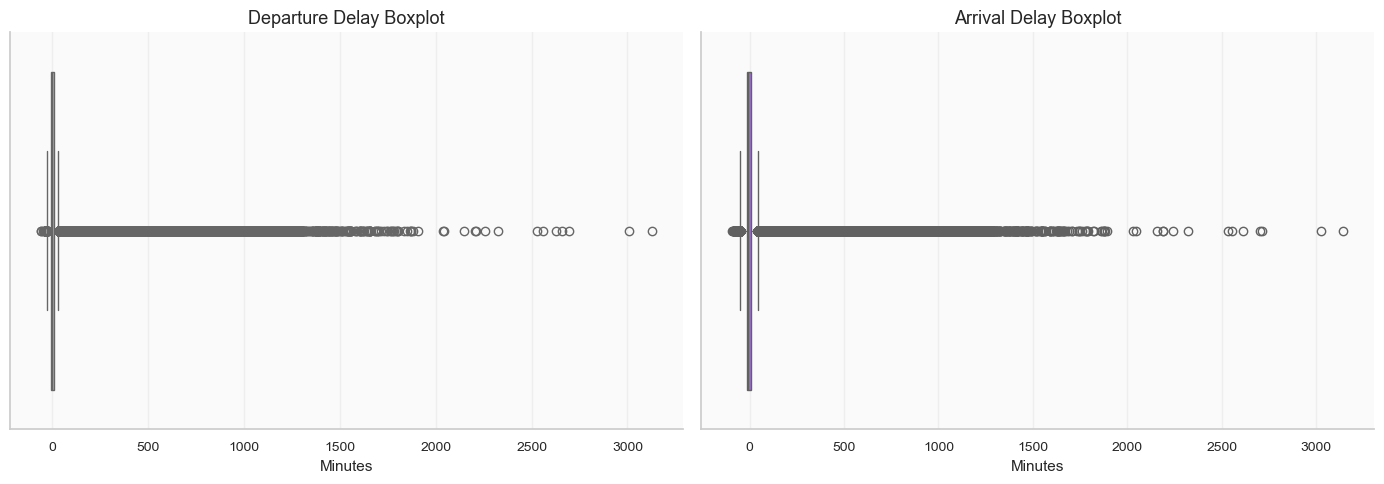

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=df.loc[operated_mask, "dep_delay"], ax=axes[0], color=ORANGE)
axes[0].set_title("Departure Delay Boxplot")
axes[0].set_xlabel("Minutes")

sns.boxplot(x=df.loc[operated_mask, "arr_delay"], ax=axes[1], color=PURPLE)
axes[1].set_title("Arrival Delay Boxplot")
axes[1].set_xlabel("Minutes")

plt.tight_layout()
plt.show()


In [49]:
delay_summary = df.loc[operated_mask, ["dep_delay", "arr_delay", "delay_in_minutes"]].describe().T
delay_summary[["mean", "std", "min", "25%", "50%", "75%", "max"]]

,mean,std,min,25%,50%,75%,max
dep_delay,12.681381,55.997008,-62.0,-6.0,-2.0,9.0,3130.0
arr_delay,7.177634,58.147074,-95.0,-15.0,-6.0,9.0,3143.0
delay_in_minutes,19.859015,113.303937,-128.0,-20.0,-8.0,17.0,6273.0


## 5. Time-based operational patterns

Since flight reliability can vary over the calendar and throughout the day, this section studies:
- month
- season
- day of week
- departure hour

The aim is to identify **when** delays are most common and whether delay buildup appears across the day.

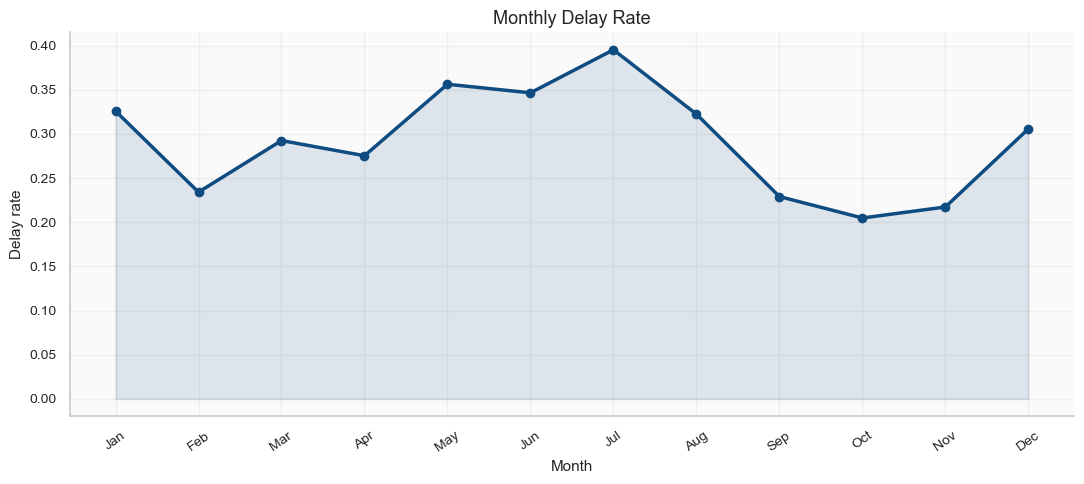

,month,month_name,flights,delay_rate,avg_dep_delay,avg_arr_delay
0,1,Jan,100691,0.325858,15.492129,10.268068
1,2,Feb,98937,0.234068,7.578520,0.743635
2,3,Mar,112887,0.292469,12.356596,6.437694
3,4,Apr,111565,0.275292,10.840174,5.505400
4,5,May,115740,0.356212,18.011439,14.010506
5,6,Jun,115908,0.346508,16.804871,11.724790
6,7,Jul,118347,0.395219,22.299484,18.208404
7,8,Aug,116622,0.322418,15.640874,11.007314
8,9,Sep,111559,0.229054,6.783890,1.104124
9,10,Oct,117461,0.204808,5.435540,-1.269170


In [50]:
monthly = (
    df.groupby(["month", "month_name"], as_index=False)
      .agg(
          flights=("IS_Delay", "size"),
          delay_rate=("IS_Delay", "mean"),
          avg_dep_delay=("dep_delay", "mean"),
          avg_arr_delay=("arr_delay", "mean")
      )
      .sort_values("month")
)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(monthly["month_name"], monthly["delay_rate"], marker="o", linewidth=2.5, color=DARK)
ax1.fill_between(monthly["month_name"], monthly["delay_rate"], color=DARK, alpha=0.12)
ax1.set_title("Monthly Delay Rate")
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay rate")
ax1.tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

monthly


### Delayed flights by month
The chart below looks at **delay frequency in absolute terms**, not just delay rate. This is useful because a month can have a moderate rate but still contribute a large number of delayed flights if flight volume is high.


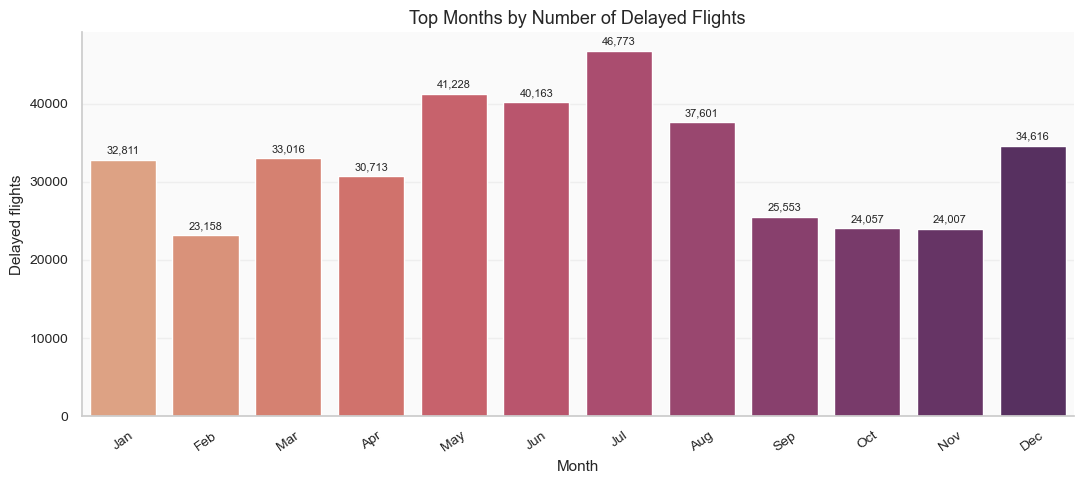

,month,month_name,delayed_flights
6,7,Jul,46773
4,5,May,41228
5,6,Jun,40163
7,8,Aug,37601
11,12,Dec,34616
2,3,Mar,33016


In [51]:
monthly_delay_counts = (
    df[df["IS_Delay"] == 1]
      .groupby(["month", "month_name"], as_index=False)
      .size()
      .rename(columns={"size": "delayed_flights"})
      .sort_values("month")
)

plt.figure(figsize=(11, 5))
ax = sns.barplot(data=monthly_delay_counts, x="month_name", y="delayed_flights", palette="flare")
plt.title("Top Months by Number of Delayed Flights")
plt.xlabel("Month")
plt.ylabel("Delayed flights")
plt.xticks(rotation=35)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=8, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.show()

monthly_delay_counts.sort_values("delayed_flights", ascending=False).head(6)


### Month × day-of-week delay heatmap
This view helps show **when delays cluster in the calendar** by combining month and weekday rather than looking at each time variable separately.


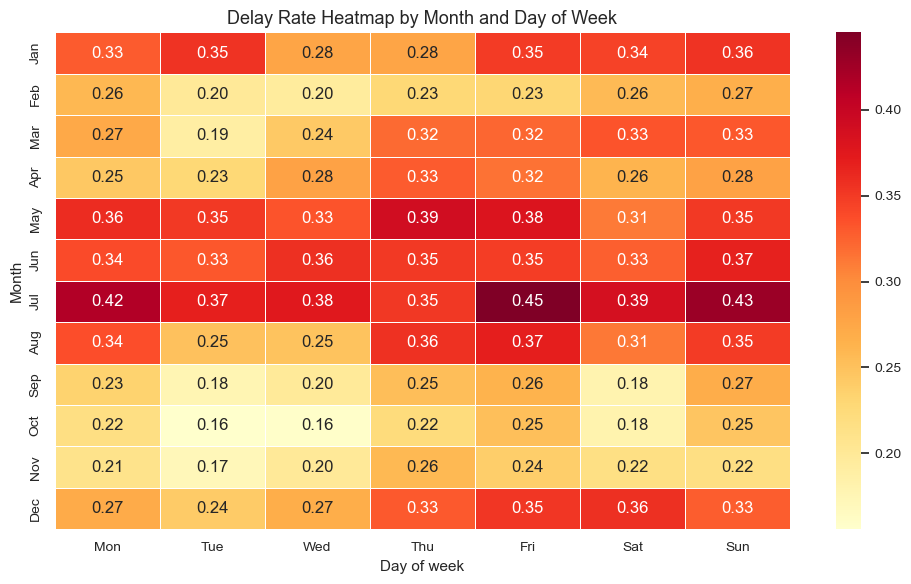

In [52]:
month_weekday_heat = (
    df.pivot_table(index="month_name", columns="weekday_name", values="IS_Delay", aggfunc="mean")
      .reindex(index=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
               columns=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
)

plt.figure(figsize=(10, 6))
sns.heatmap(month_weekday_heat, cmap="YlOrRd", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Delay Rate Heatmap by Month and Day of Week")
plt.xlabel("Day of week")
plt.ylabel("Month")
plt.tight_layout()
plt.show()


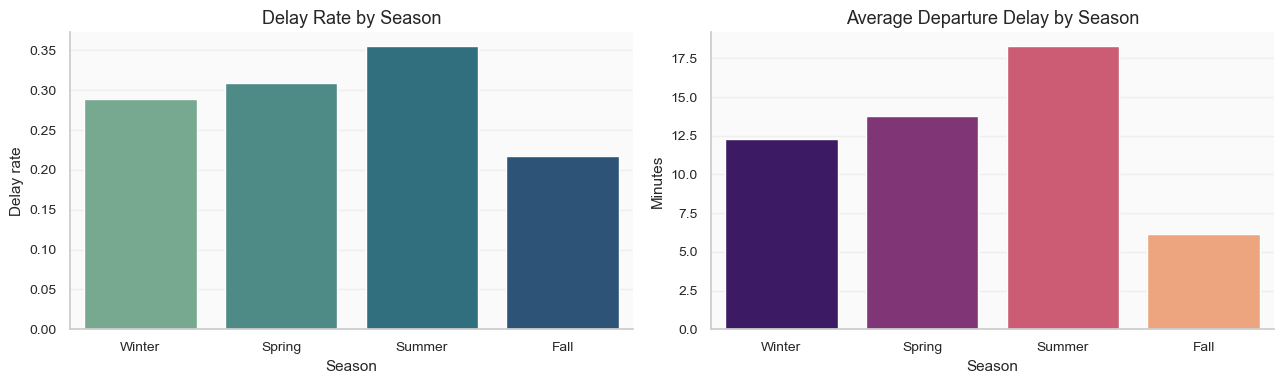

,Season,flights,delay_rate,avg_dep_delay
0,Winter,312859,0.289539,12.309817
1,Spring,340192,0.308523,13.783178
2,Summer,350877,0.354931,18.271263
3,Fall,339515,0.216830,6.142830


In [53]:
seasonal = (
    df.groupby("Season", observed=True, as_index=False)
      .agg(
          flights=("IS_Delay", "size"),
          delay_rate=("IS_Delay", "mean"),
          avg_dep_delay=("dep_delay", "mean")
      )
      .sort_values("Season")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=seasonal, x="Season", y="delay_rate", ax=axes[0], palette="crest")
axes[0].set_title("Delay Rate by Season")
axes[0].set_ylabel("Delay rate")

sns.barplot(data=seasonal, x="Season", y="avg_dep_delay", ax=axes[1], palette="magma")
axes[1].set_title("Average Departure Delay by Season")
axes[1].set_ylabel("Minutes")

plt.tight_layout()
plt.show()

seasonal


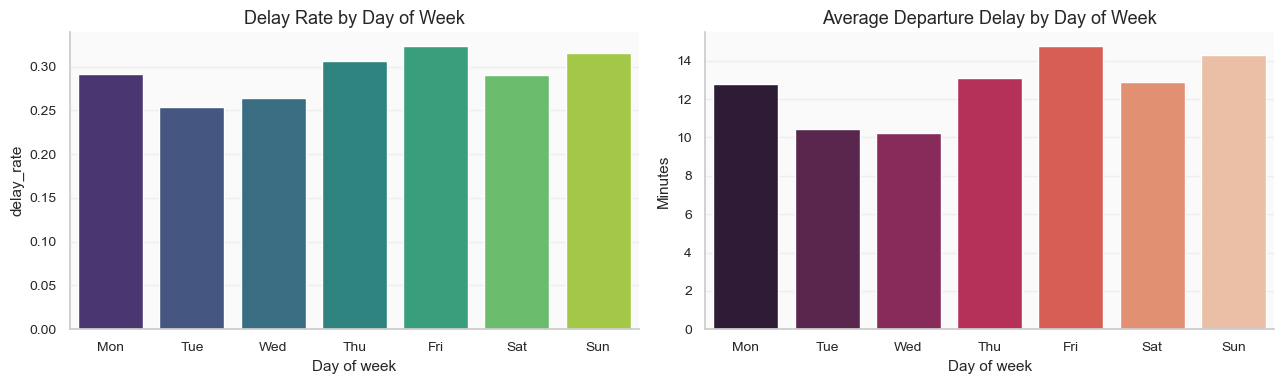

,weekday_name,flights,delay_rate,avg_dep_delay
1,Mon,204257,0.291207,12.770715
5,Tue,185318,0.254169,10.444242
6,Wed,184812,0.264793,10.251266
4,Thu,197283,0.306575,13.115180
0,Fri,199956,0.323111,14.740548
2,Sat,173756,0.290534,12.863982
3,Sun,198061,0.316084,14.278859


In [54]:
weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
weekday_perf = (
    df.groupby("weekday_name", as_index=False)
      .agg(
          flights=("IS_Delay", "size"),
          delay_rate=("IS_Delay", "mean"),
          avg_dep_delay=("dep_delay", "mean")
      )
)
weekday_perf["weekday_name"] = pd.Categorical(weekday_perf["weekday_name"], categories=weekday_order, ordered=True)
weekday_perf = weekday_perf.sort_values("weekday_name")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=weekday_perf, x="weekday_name", y="delay_rate", ax=axes[0], palette="viridis")
axes[0].set_title("Delay Rate by Day of Week")
axes[0].set_xlabel("Day of week")

sns.barplot(data=weekday_perf, x="weekday_name", y="avg_dep_delay", ax=axes[1], palette="rocket")
axes[1].set_title("Average Departure Delay by Day of Week")
axes[1].set_xlabel("Day of week")
axes[1].set_ylabel("Minutes")

plt.tight_layout()
plt.show()

weekday_perf


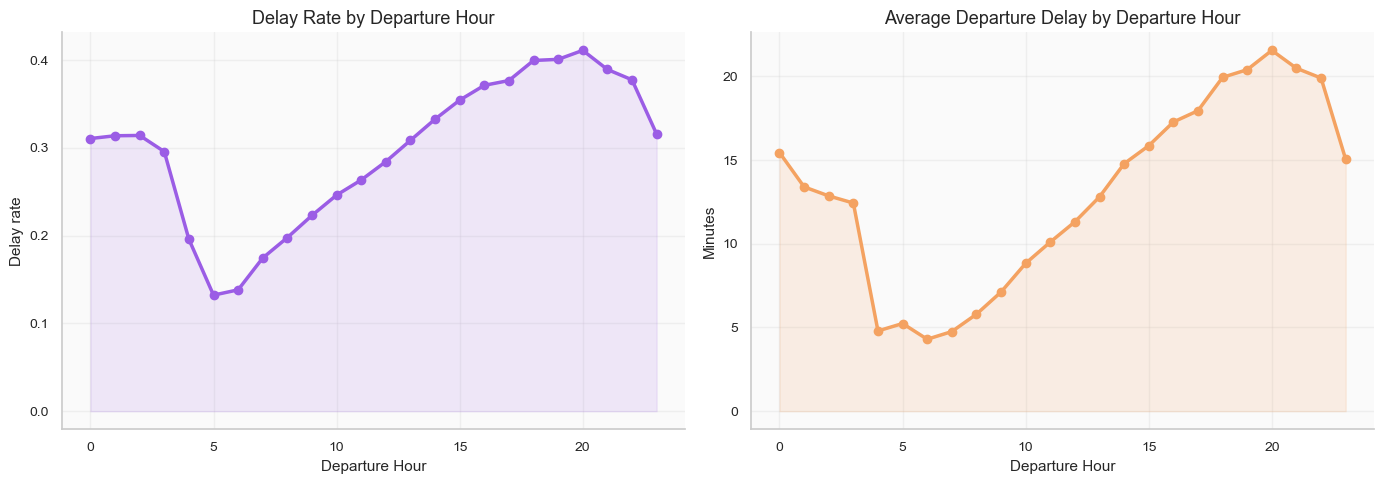

,Departure_Hour,flights,delay_rate,avg_dep_delay
0,0,2356,0.310696,15.446944
1,1,787,0.313850,13.396442
2,2,331,0.314199,12.858006
3,3,213,0.295775,12.431925
4,4,97,0.195876,4.793814
5,5,38945,0.132263,5.237771
6,6,96233,0.138310,4.298099
7,7,94946,0.174626,4.756556
8,8,91803,0.197848,5.793863
9,9,75239,0.223116,7.119552


In [55]:
hourly = (
    df.groupby("Departure_Hour", as_index=False)
      .agg(
          flights=("IS_Delay", "size"),
          delay_rate=("IS_Delay", "mean"),
          avg_dep_delay=("dep_delay", "mean")
      )
      .sort_values("Departure_Hour")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hourly["Departure_Hour"], hourly["delay_rate"], marker="o", linewidth=2.5, color=PURPLE)
axes[0].fill_between(hourly["Departure_Hour"], hourly["delay_rate"], color=PURPLE, alpha=0.12)
axes[0].set_title("Delay Rate by Departure Hour")
axes[0].set_xlabel("Departure Hour")
axes[0].set_ylabel("Delay rate")

axes[1].plot(hourly["Departure_Hour"], hourly["avg_dep_delay"], marker="o", linewidth=2.5, color=ORANGE)
axes[1].fill_between(hourly["Departure_Hour"], hourly["avg_dep_delay"], color=ORANGE, alpha=0.15)
axes[1].set_title("Average Departure Delay by Departure Hour")
axes[1].set_xlabel("Departure Hour")
axes[1].set_ylabel("Minutes")

plt.tight_layout()
plt.show()

hourly


## 6. Airline performance comparison

This section compares airlines on:
- flight volume
- delay rate
- average departure delay
- average arrival delay

To avoid unstable rankings, airline comparisons are best interpreted together with volume rather than in isolation.

In [56]:
airline_perf = (
    df.groupby("op_unique_carrier", as_index=False)
      .agg(
          flights=("IS_Delay", "size"),
          delay_rate=("IS_Delay", "mean"),
          avg_dep_delay=("dep_delay", "mean"),
          avg_arr_delay=("arr_delay", "mean")
      )
      .sort_values("flights", ascending=False)
)

airline_perf

,op_unique_carrier,flights,delay_rate,avg_dep_delay,avg_arr_delay
13,WN,267126,0.331368,11.699120,5.081800
4,DL,191481,0.248865,10.088280,3.649746
1,AA,185345,0.347287,20.511166,15.182001
12,UA,143976,0.275108,12.175689,6.079395
11,OO,141277,0.247769,11.322133,7.432123
14,YX,57421,0.180909,3.825203,-1.878860
8,MQ,51791,0.284605,10.243594,6.554672
9,NK,51555,0.328077,15.134032,8.601959
2,AS,47355,0.316355,7.633999,4.482568
3,B6,47098,0.333454,17.427364,10.828358


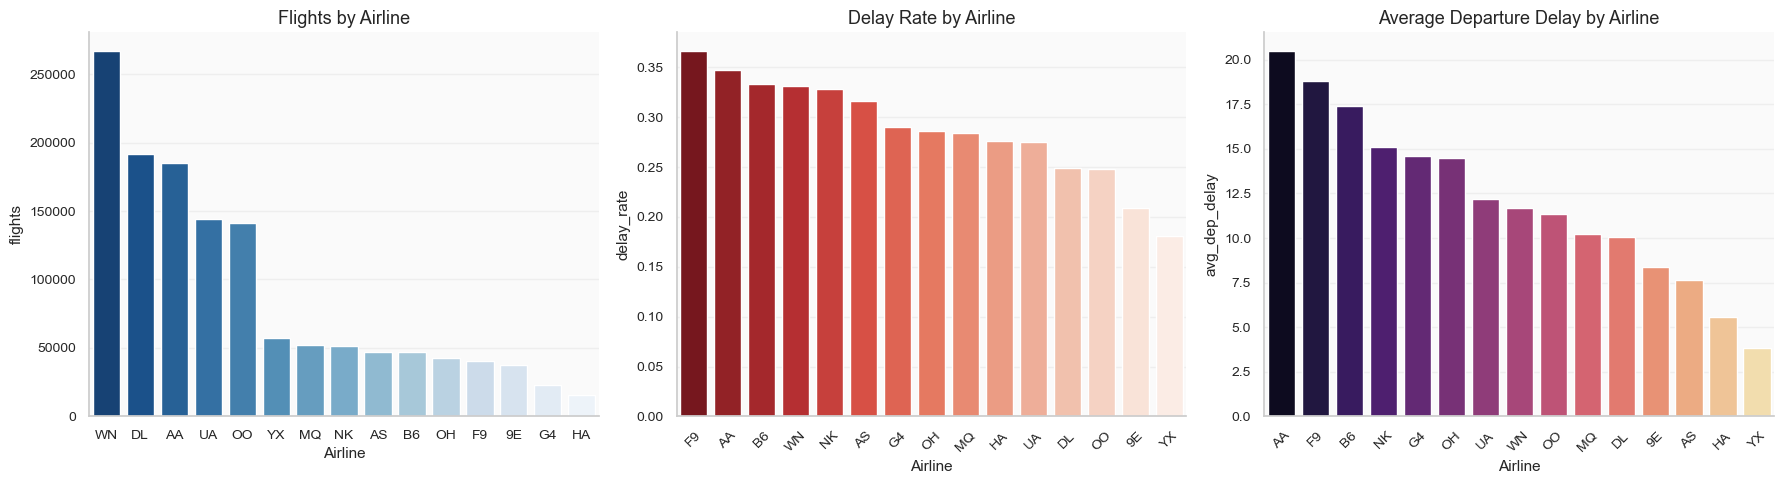

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=airline_perf.sort_values("flights", ascending=False), x="op_unique_carrier", y="flights", ax=axes[0], palette="Blues_r")
axes[0].set_title("Flights by Airline")
axes[0].set_xlabel("Airline")

sns.barplot(data=airline_perf.sort_values("delay_rate", ascending=False), x="op_unique_carrier", y="delay_rate", ax=axes[1], palette="Reds_r")
axes[1].set_title("Delay Rate by Airline")
axes[1].set_xlabel("Airline")
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(data=airline_perf.sort_values("avg_dep_delay", ascending=False), x="op_unique_carrier", y="avg_dep_delay", ax=axes[2], palette="magma")
axes[2].set_title("Average Departure Delay by Airline")
axes[2].set_xlabel("Airline")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [58]:
# More defensible ranking: impose a minimum volume threshold
min_airline_flights = 5000
airline_ranked = airline_perf[airline_perf["flights"] >= min_airline_flights].copy()

airline_ranked.sort_values(["delay_rate", "avg_dep_delay"], ascending=[True, True]).head(10)

,op_unique_carrier,flights,delay_rate,avg_dep_delay,avg_arr_delay
14,YX,57421,0.180909,3.825203,-1.878860
0,9E,37416,0.208601,8.387080,1.919526
11,OO,141277,0.247769,11.322133,7.432123
4,DL,191481,0.248865,10.088280,3.649746
12,UA,143976,0.275108,12.175689,6.079395
7,HA,15560,0.276542,5.551542,4.339396
8,MQ,51791,0.284605,10.243594,6.554672
10,OH,42544,0.286362,14.473228,10.715565
6,G4,22931,0.289826,14.608826,10.286730
2,AS,47355,0.316355,7.633999,4.482568


## 7. Origin and destination analysis

Operational performance can also vary by where flights begin and end.  
This section studies:
- busiest origin cities
- busiest destination cities
- locations with higher delay rates
- the importance of comparing **volume** together with reliability

In [59]:
origin_perf = (
    df.groupby("origin_city", as_index=False)
      .agg(
          flights=("IS_Delay", "size"),
          delay_rate=("IS_Delay", "mean"),
          avg_dep_delay=("dep_delay", "mean")
      )
      .sort_values("flights", ascending=False)
)

dest_perf = (
    df.groupby("dest_city", as_index=False)
      .agg(
          flights=("IS_Delay", "size"),
          delay_rate=("IS_Delay", "mean"),
          avg_arr_delay=("arr_delay", "mean")
      )
      .sort_values("flights", ascending=False)
)

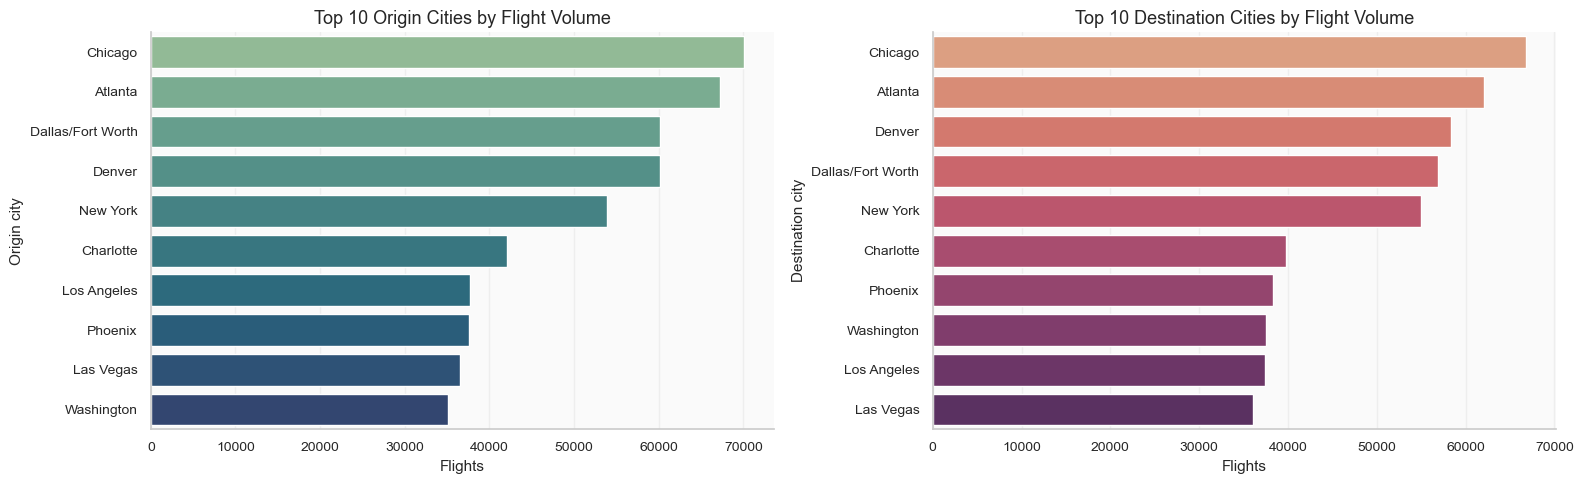

In [60]:
top_n = 10

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=origin_perf.head(top_n), y="origin_city", x="flights", ax=axes[0], palette="crest")
axes[0].set_title(f"Top {top_n} Origin Cities by Flight Volume")
axes[0].set_xlabel("Flights")
axes[0].set_ylabel("Origin city")

sns.barplot(data=dest_perf.head(top_n), y="dest_city", x="flights", ax=axes[1], palette="flare")
axes[1].set_title(f"Top {top_n} Destination Cities by Flight Volume")
axes[1].set_xlabel("Flights")
axes[1].set_ylabel("Destination city")

plt.tight_layout()
plt.show()


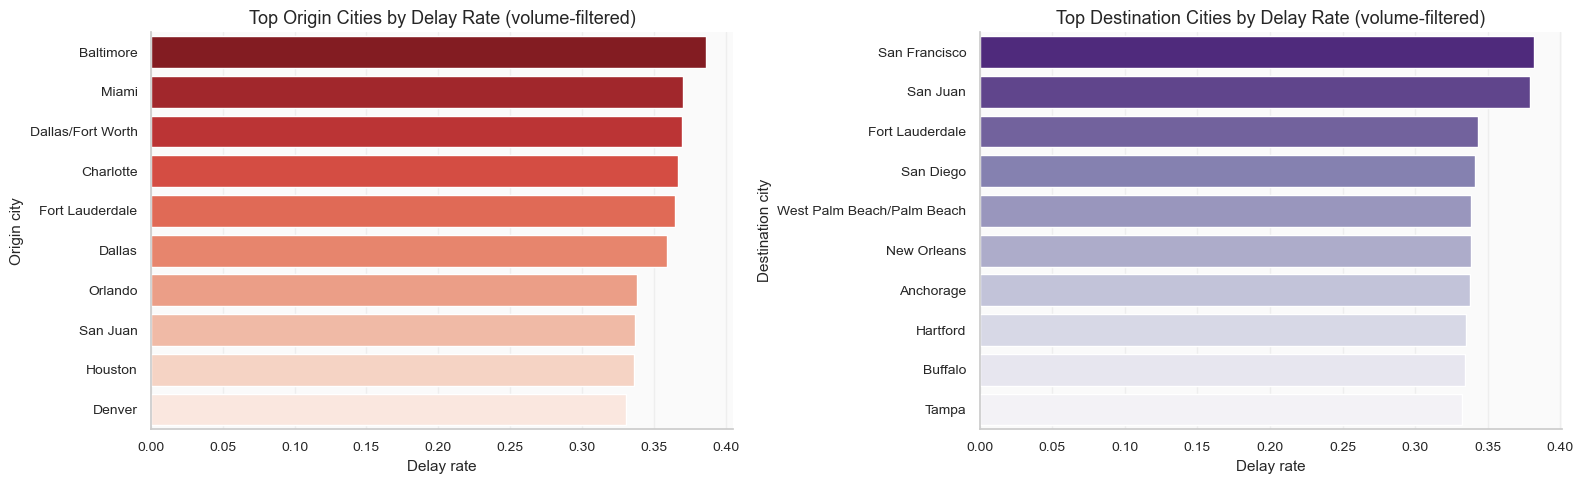

(           origin_city  flights  delay_rate  avg_dep_delay
 22           Baltimore    19050    0.385932      15.289921
 198              Miami    21065    0.370425      19.245906
 74   Dallas/Fort Worth    60201    0.369296      18.892161
 55           Charlotte    42029    0.366771      18.624759
 104    Fort Lauderdale    17524    0.364700      16.847580
 73              Dallas    13691    0.359360      14.211380
 231            Orlando    30301    0.338339      15.581730
 275           San Juan     6744    0.336744      17.272390
 138            Houston    33335    0.335893      16.264557
 79              Denver    60091    0.330282      13.040189,
                       dest_city  flights  delay_rate  avg_arr_delay
 273               San Francisco    26013    0.382078      12.827202
 275                    San Juan     7002    0.379035      12.277207
 104             Fort Lauderdale    17932    0.343130       9.555989
 272                   San Diego    18036    0.340874       8.8

In [61]:
min_city_flights = 3000

origin_ranked = origin_perf[origin_perf["flights"] >= min_city_flights].sort_values("delay_rate", ascending=False).head(10)
dest_ranked = dest_perf[dest_perf["flights"] >= min_city_flights].sort_values("delay_rate", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=origin_ranked, y="origin_city", x="delay_rate", ax=axes[0], palette="Reds_r")
axes[0].set_title("Top Origin Cities by Delay Rate (volume-filtered)")
axes[0].set_xlabel("Delay rate")
axes[0].set_ylabel("Origin city")

sns.barplot(data=dest_ranked, y="dest_city", x="delay_rate", ax=axes[1], palette="Purples_r")
axes[1].set_title("Top Destination Cities by Delay Rate (volume-filtered)")
axes[1].set_xlabel("Delay rate")
axes[1].set_ylabel("Destination city")

plt.tight_layout()
plt.show()

origin_ranked, dest_ranked


### Which origin airports/cities contribute the most delayed flights?
For presentation purposes, this section looks at **absolute delayed flight counts** from the origin side. This is different from delay rate: it highlights the places that contribute the largest number of delayed departures overall.


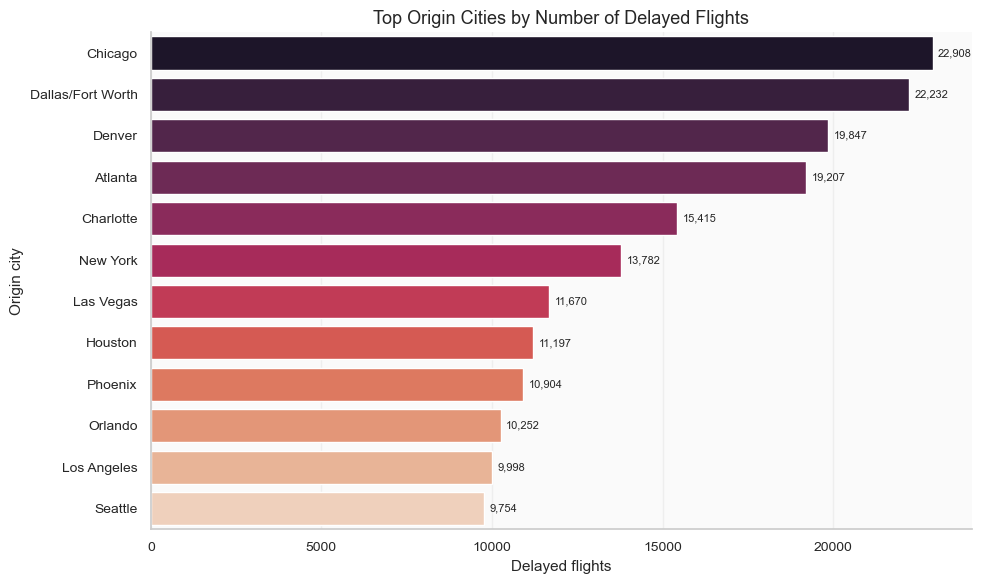

,origin_city,delayed_flights
60,Chicago,22908
74,Dallas/Fort Worth,22232
79,Denver,19847
17,Atlanta,19207
55,Charlotte,15415
218,New York,13782
173,Las Vegas,11670
137,Houston,11197
240,Phoenix,10904
230,Orlando,10252


In [62]:
origin_delay_counts = (
    df[df["IS_Delay"] == 1]
      .groupby("origin_city", as_index=False)
      .size()
      .rename(columns={"size": "delayed_flights"})
      .sort_values("delayed_flights", ascending=False)
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=origin_delay_counts.head(12), y="origin_city", x="delayed_flights", palette="rocket")
plt.title("Top Origin Cities by Number of Delayed Flights")
plt.xlabel("Delayed flights")
plt.ylabel("Origin city")
for p in ax.patches:
    ax.annotate(f"{int(p.get_width()):,}", (p.get_width(), p.get_y()+p.get_height()/2), xytext=(4, 0), textcoords='offset points', va='center', fontsize=8)
plt.tight_layout()
plt.show()

origin_delay_counts.head(12)


### Volume vs delay-rate view for major origin cities
This bubble chart is useful because it balances **size** and **reliability**. Large circles indicate busier origin cities; positions further right and higher up indicate locations with stronger delay burden.


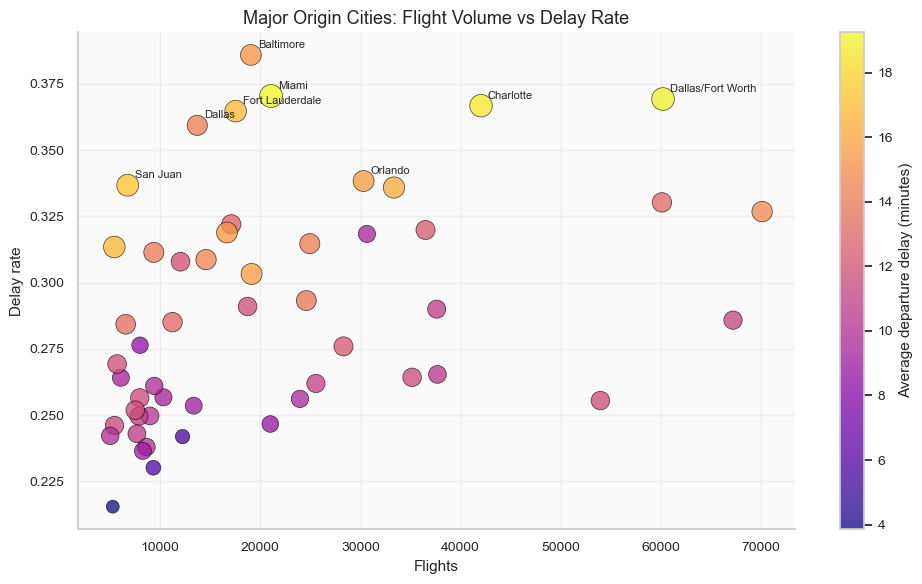

In [63]:
major_origins = origin_perf[origin_perf["flights"] >= 5000].copy()
major_origins["avg_delay_positive"] = major_origins["avg_dep_delay"].clip(lower=0)

plt.figure(figsize=(10, 6))
plt.scatter(
    major_origins["flights"],
    major_origins["delay_rate"],
    s=major_origins["avg_delay_positive"] * 12 + 40,
    c=major_origins["avg_delay_positive"],
    cmap="plasma",
    alpha=0.75,
    edgecolors="black",
    linewidth=0.5
)

for _, row in major_origins.sort_values("delay_rate", ascending=False).head(8).iterrows():
    plt.annotate(row["origin_city"], (row["flights"], row["delay_rate"]), xytext=(5, 5), textcoords="offset points", fontsize=8)

cbar = plt.colorbar()
cbar.set_label("Average departure delay (minutes)")
plt.title("Major Origin Cities: Flight Volume vs Delay Rate")
plt.xlabel("Flights")
plt.ylabel("Delay rate")
plt.tight_layout()
plt.show()


## 8. Route-level analysis

Route analysis helps determine whether delay concentration is tied to specific city-pairs rather than only to individual origins or destinations.

To keep the results credible, routes are ranked with a minimum flight threshold.

In [64]:
route_perf = (
    df.groupby("route", as_index=False)
      .agg(
          flights=("IS_Delay", "size"),
          delay_rate=("IS_Delay", "mean"),
          avg_dep_delay=("dep_delay", "mean"),
          avg_arr_delay=("arr_delay", "mean")
      )
      .sort_values("flights", ascending=False)
)

route_perf.head(10)

,route,flights,delay_rate,avg_dep_delay,avg_arr_delay
1100,Chicago → New York,3121,0.326498,15.776995,11.129125
3746,New York → Chicago,2910,0.255670,14.054983,5.627835
651,Boston → New York,2712,0.236726,8.660398,2.536504
3736,New York → Boston,2593,0.249518,13.452372,5.711917
2376,Honolulu → Kahului,2383,0.204364,2.081410,0.706672
277,Atlanta → New York,2343,0.316688,15.217670,7.670508
3111,Los Angeles → San Francisco,2295,0.399129,12.661874,13.763399
3729,New York → Atlanta,2272,0.297535,15.154489,4.810739
2658,Kahului → Honolulu,2271,0.213122,1.661823,0.144430
678,Boston → Washington,2217,0.216960,8.896256,3.262968


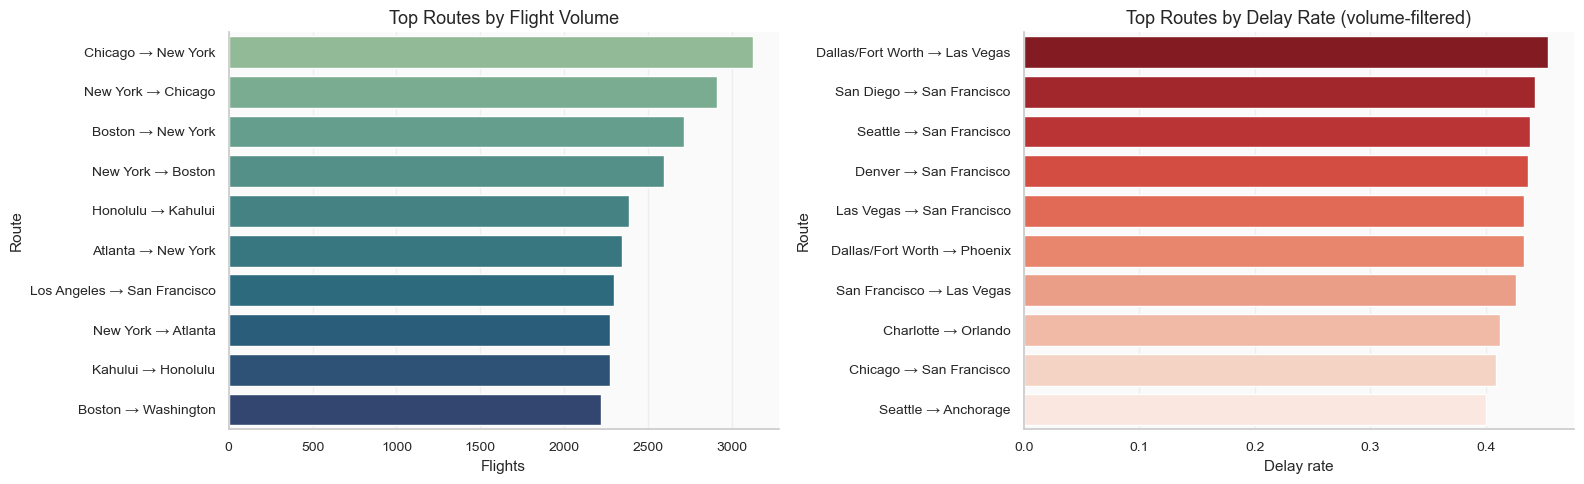

In [65]:
min_route_flights = 1000
route_ranked = route_perf[route_perf["flights"] >= min_route_flights].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=route_ranked.sort_values("flights", ascending=False).head(10), y="route", x="flights", ax=axes[0], palette="crest")
axes[0].set_title("Top Routes by Flight Volume")
axes[0].set_xlabel("Flights")
axes[0].set_ylabel("Route")

sns.barplot(data=route_ranked.sort_values("delay_rate", ascending=False).head(10), y="route", x="delay_rate", ax=axes[1], palette="Reds_r")
axes[1].set_title("Top Routes by Delay Rate (volume-filtered)")
axes[1].set_xlabel("Delay rate")
axes[1].set_ylabel("Route")

plt.tight_layout()
plt.show()


## 9. Delay reason analysis

Even though this notebook is not weather-focused, the delay reason columns are still important from the flight perspective because they explain **operational sources of delay**.

This section compares:
- `carrier_delay`
- `weather_delay`
- `nas_delay`
- `security_delay`
- `late_aircraft_delay`

In [66]:
delay_reason_cols = [
    "carrier_delay", "weather_delay", "nas_delay",
    "security_delay", "late_aircraft_delay"
]

reason_minutes = df[delay_reason_cols].sum().sort_values(ascending=False).rename("total_minutes")
reason_share = (reason_minutes / reason_minutes.sum()).rename("share_of_reason_minutes")

pd.concat([reason_minutes, reason_share], axis=1)

,total_minutes,share_of_reason_minutes
late_aircraft_delay,8134381,0.404492
carrier_delay,6969261,0.346555
nas_delay,3759541,0.186948
weather_delay,1212904,0.060313
security_delay,34029,0.001692


In [67]:
reason_positive_counts = (df[delay_reason_cols] > 0).sum().sort_values(ascending=False).rename("flights_affected")
reason_positive_rate = (df[delay_reason_cols].gt(0).mean()).sort_values(ascending=False).rename("share_of_flights")

pd.concat([reason_positive_counts, reason_positive_rate], axis=1)

,flights_affected,share_of_flights
carrier_delay,152561,0.113560
late_aircraft_delay,142778,0.106278
nas_delay,138346,0.102979
weather_delay,17412,0.012961
security_delay,1459,0.001086


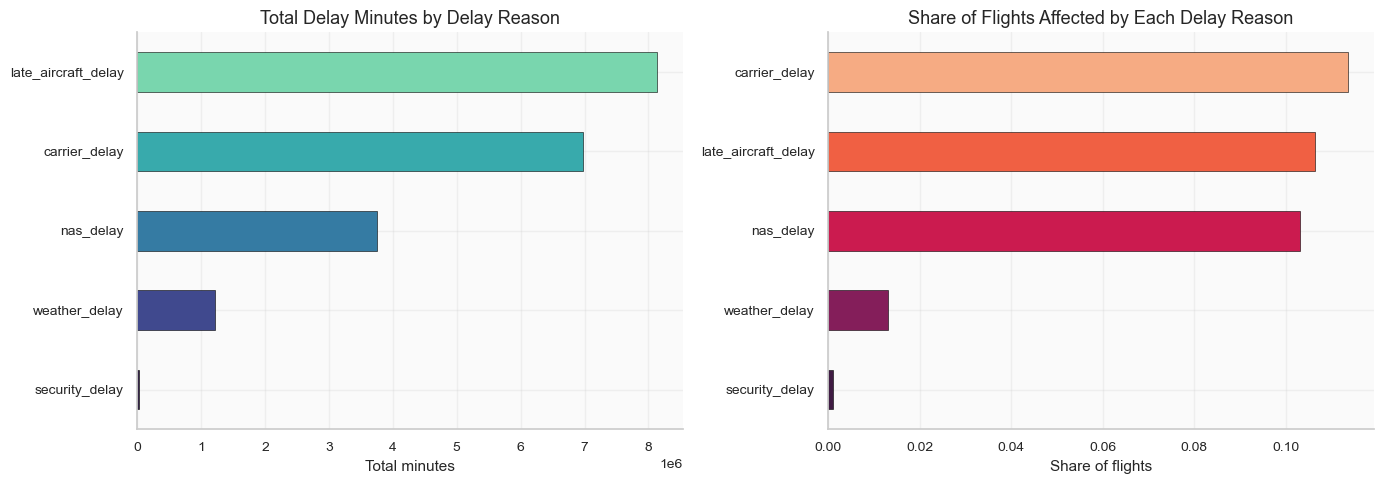

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

reason_minutes.sort_values().plot(kind="barh", ax=axes[0], color=sns.color_palette("mako", 5), edgecolor='black', linewidth=0.4)
axes[0].set_title("Total Delay Minutes by Delay Reason")
axes[0].set_xlabel("Total minutes")

reason_positive_rate.sort_values().plot(kind="barh", ax=axes[1], color=sns.color_palette("rocket", 5), edgecolor='black', linewidth=0.4)
axes[1].set_title("Share of Flights Affected by Each Delay Reason")
axes[1].set_xlabel("Share of flights")

plt.tight_layout()
plt.show()


## 10. Relationships among key numeric variables

This section checks whether key flight variables move together.  
It is especially useful for understanding:
- whether late departures tend to remain late on arrival
- whether total delay closely tracks component delay metrics
- which operational variables may be informative in later modeling

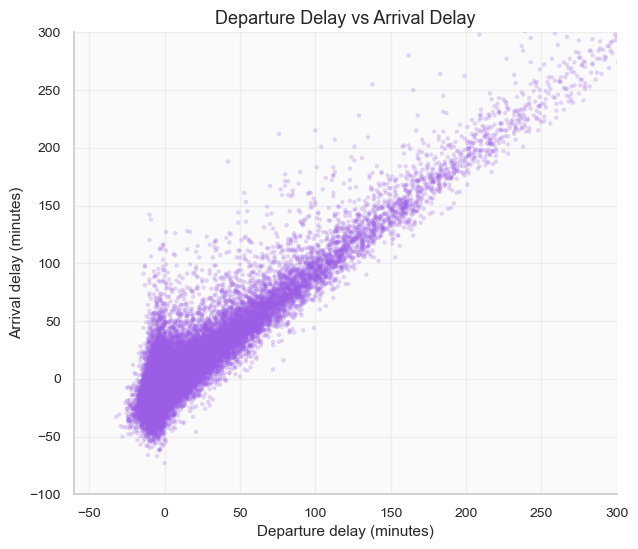

Correlation: 0.971


In [69]:
sample_n = min(50000, len(df))
plot_df = df.loc[operated_mask, ["dep_delay", "arr_delay"]].dropna().sample(sample_n, random_state=42)

plt.figure(figsize=(7, 6))
plt.scatter(plot_df["dep_delay"], plot_df["arr_delay"], alpha=0.25, s=10, color=PURPLE, edgecolors='none')
plt.title("Departure Delay vs Arrival Delay")
plt.xlabel("Departure delay (minutes)")
plt.ylabel("Arrival delay (minutes)")
plt.xlim(-60, 300)
plt.ylim(-100, 300)
plt.show()

print("Correlation:", df.loc[operated_mask, ["dep_delay", "arr_delay"]].corr().iloc[0, 1].round(3))


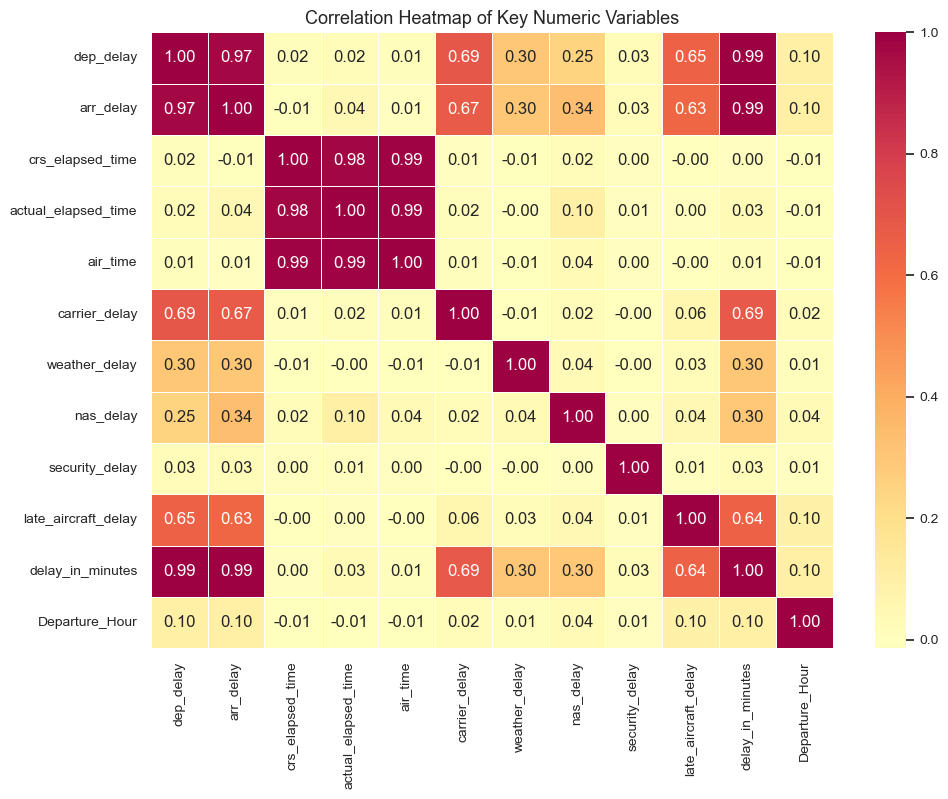

In [70]:
corr_cols = [
    "dep_delay", "arr_delay", "crs_elapsed_time", "actual_elapsed_time", "air_time",
    "carrier_delay", "weather_delay", "nas_delay", "security_delay", "late_aircraft_delay",
    "delay_in_minutes", "Departure_Hour"
]

corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap="Spectral_r", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Key Numeric Variables")
plt.show()


## 11. Additional operational insight: scheduled vs actual time

This section adds one more flight-centered angle by comparing scheduled time, actual elapsed time, and air time.  
It helps answer whether longer or operationally stretched flights are associated with heavier delay behavior.

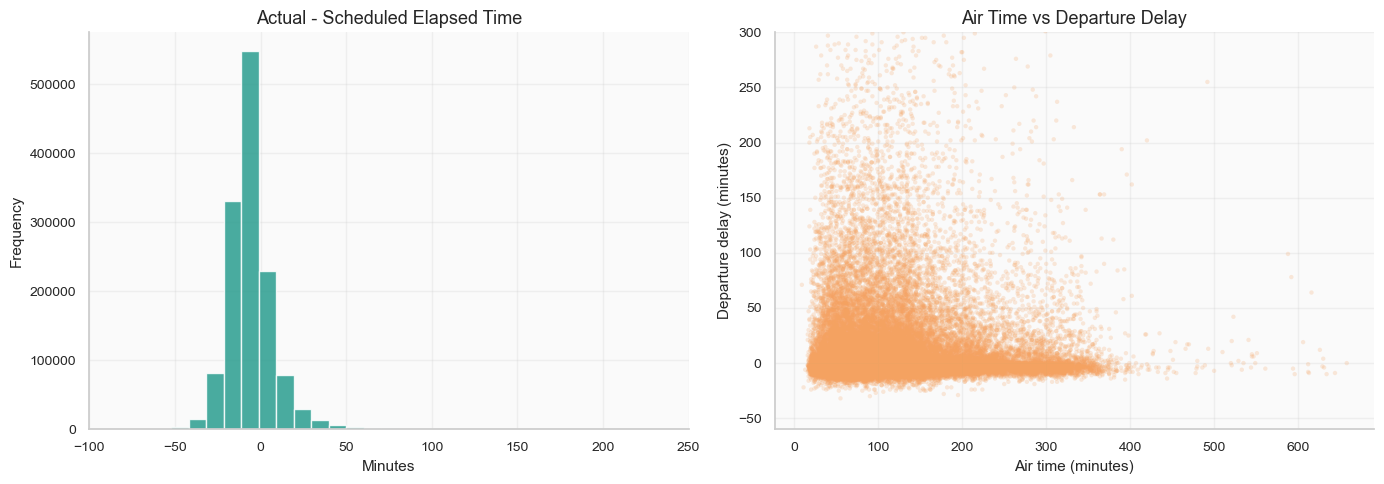

In [71]:
elapsed_diff = df["actual_elapsed_time"] - df["crs_elapsed_time"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(elapsed_diff.dropna(), bins=80, color=GREEN, alpha=0.85, edgecolor='white')
axes[0].set_title("Actual - Scheduled Elapsed Time")
axes[0].set_xlabel("Minutes")
axes[0].set_ylabel("Frequency")
axes[0].set_xlim(-100, 250)

sample2 = df.loc[operated_mask, ["air_time", "dep_delay"]].dropna().sample(sample_n, random_state=42)
axes[1].scatter(sample2["air_time"], sample2["dep_delay"], alpha=0.22, s=10, color=ORANGE, edgecolors='none')
axes[1].set_title("Air Time vs Departure Delay")
axes[1].set_xlabel("Air time (minutes)")
axes[1].set_ylabel("Departure delay (minutes)")
axes[1].set_ylim(-60, 300)

plt.tight_layout()
plt.show()


## 12. Supporting context from the merged weather fields

This is **not** a full weather analysis.  
The purpose of this section is simply to document the weather side of the merged file from a flight-EDA perspective:
- whether weather measurements are present
- whether coverage is complete enough to support later merged analyses

In [72]:
weather_cols = ["Temperature_C", "Humidity_pct", "Precipitation_mm", "Wind_Speed_kmh", "Weather_Data_Present"]

coverage = pd.DataFrame({
    "missing_count": df[weather_cols].isna().sum(),
    "missing_pct": 100 * df[weather_cols].isna().mean()
}).sort_values("missing_pct", ascending=False)

coverage

,missing_count,missing_pct
Temperature_C,1234604,91.898503
Humidity_pct,1234604,91.898503
Precipitation_mm,1234604,91.898503
Wind_Speed_kmh,1234604,91.898503
Weather_Data_Present,0,0.000000


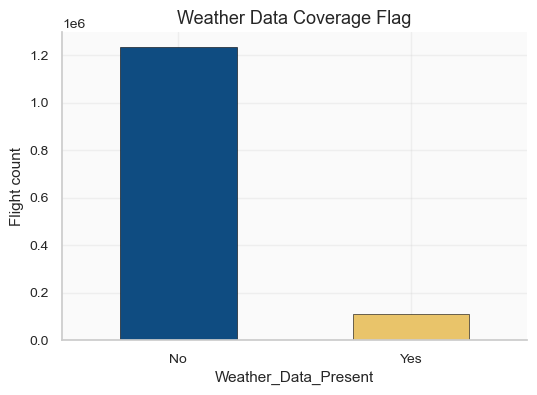

In [73]:
if "Weather_Data_Present" in df.columns:
    plt.figure(figsize=(6, 4))
    df["Weather_Data_Present"].value_counts(dropna=False).plot(kind="bar", color=[DARK, GOLD], edgecolor='black', linewidth=0.4)
    plt.title("Weather Data Coverage Flag")
    plt.xlabel("Weather_Data_Present")
    plt.ylabel("Flight count")
    plt.xticks(rotation=0)
    plt.show()


## 13. Limitations and interpretation boundaries

A solid final EDA should also state its limits clearly.

### Key limitations in this file
- The dataset is merged, but this notebook intentionally uses a **flight-focused lens**.
- Weather coverage is incomplete for many rows, so merged weather context should be interpreted cautiously.
- The `cancelled` column may have limited or no variation in this specific file; if so, cancellation comparisons are constrained by the data provided.
- Rankings for airlines, cities, and routes can be misleading when group sizes are tiny, so minimum-volume thresholds are used where possible.
- `IS_Delay` is based on **departure delay > 15 minutes**, which is useful for classification but does not capture every form of disruption.

## 14. Final summary and transition to modeling

This EDA is meant to support the next project stage, not just describe the data.  
A strong final summary should connect findings back to the classification task.

### What this notebook should establish
- whether delay behavior is common enough and structured enough to model
- which time-based and airline-based patterns appear strongest
- whether route and location effects matter operationally
- which delay reasons dominate the delay landscape
- which numeric relationships look useful for predictive modeling

### Modeling bridge

Based on this EDA, the next stage can focus on predicting `IS_Delay` using operational variables available prior to departure, such as:

- airline  
- departure hour  
- month / season / weekday  
- origin and destination information  
- scheduled or planned elapsed-time variables  
- merged weather variables where coverage is adequate  

It is important to note that variables such as realized delay values and delay-reason fields (e.g., carrier delay, weather delay) will not be used as model inputs, as they are only known after the outcome occurs and would introduce data leakage.